In [11]:
%reset
low_memory=False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Nothing done.


## 2.2 Problem setting

### 🏢 The Business Case: Contoso's Advertising Challenge

Meet Contoso, a company that wants to optimize their advertising strategy. Here's their situation:

#### Current Scenario
- They advertise across three channels: 📺 TV, 📻 Radio, and 📰 Newspaper
- They track monthly sales data (in thousands of units)
- They record advertising spend (in thousands of dollars) for each channel
- They need help understanding which advertising channels are most effective

#### Your Role
As a data scientist, you'll help Contoso:
1. Analyze the relationship between advertising spend and sales
2. Build models to predict sales based on advertising
3. Determine which channels give the best return on investment

#### The Data
You'll work with a dataset containing:
- Sales figures (dependent variable)
- Advertising spend on TV (independent variable)
- Advertising spend on Radio (independent variable)
- Advertising spend on Newspaper (independent variable)

Let's help Contoso make smarter advertising decisions! 💡

## 2.3 Model

Go to canvas and donload the file "Advertising.csv" from module 2. This data contains the required dataset.

In [12]:
df = pd.read_csv('/Users/mohammedsadmanuddin/data science fund/Linear regression/Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### 🤔 Initial Data Analysis

#### Question 1: Exploring the Dataset
Look at the columns and data carefully. Think like a business analyst:
- What should we predict? (dependent variable)=dependent var is the thing which is the result or what we predict(Y)..here sales is the dependent var
- What data can we use to make predictions? (independent variables)=independent variable is the thing which we use to make the prediction(X)..here 
- Which predictions would be most valuable for the business?=sales

#### Question 2: Thinking About the Model
Before we start plotting, let's think about the real-world relationship between advertising and sales:
- Would you expect linear regression to work here? Why?=Yes...from the dataset i can see the more the spending in individual way the more the sales.
- What kind of relationship would you expect between ad spend and sales?=the relationship looks approx linear..sales=b0+b1(tv)+b2(radio)+b3(newspaper)
- Are there any limitations to consider?=I think the one limitation that can cause the model to distort which is outliers

Before we train this new model, we first want to create a column where all our information is stored. We will call this column 'total_spent'.

Since we are working with an actual dataset, we also want to split our data. in a train and a test set. This ensure we can properly evaluate our model and test in on data it has never seen before.

In [13]:
df['Total']=df['TV']+df['newspaper']+df['radio']
#df['Total']
X = df['Total'].to_numpy().reshape(-1,1)
y=df['sales']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=101)

### 🔍 Understanding Model Parameters

#### Question 3: Notice the two parameters called "test_size" and "random_state". "test_size" is required while "random_state" is an optional parameter. Read the sklearn documentation to know more about them. What do these variables mean?

=The testsize parameter means spliting the dataset...0.3 test size means 30% testing data...the rest is training(70%)
=the random state means controlling the random spliting...so eveytime i run it will be fixed and wont change the split

Review the [sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) for details!

Now that you have prepared your data it's time to train the model. Make sure to only use the training data!

In [14]:
Model=LinearRegression()
Model.fit(X_train,y_train)

LinearRegression()

##### Question 4:  Plot a graph to show the amount of sales in function of the total amount spent on advertising. Draw a line using Beta 0 and Beta 1 to show our model. Does this confirm/deny your earlier assumptions about whether or not to choose linear regression?

4.54113317082423
0.047387540484483216


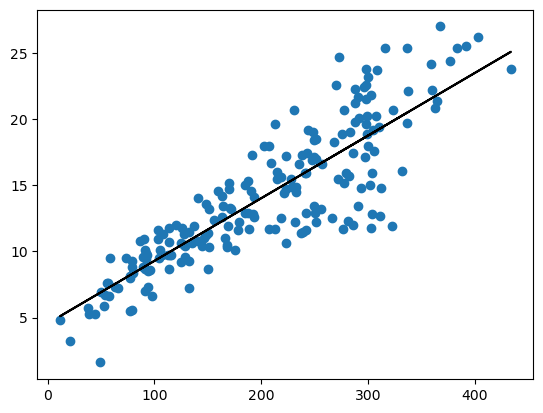

In [15]:
Beta0=Model.intercept_
print(Beta0)
Beta1=Model.coef_[0]
print(Beta1)
y_pred=Beta0+Beta1 * X
plt.scatter(X,y)
plt.plot(X,y_pred,color='Black')


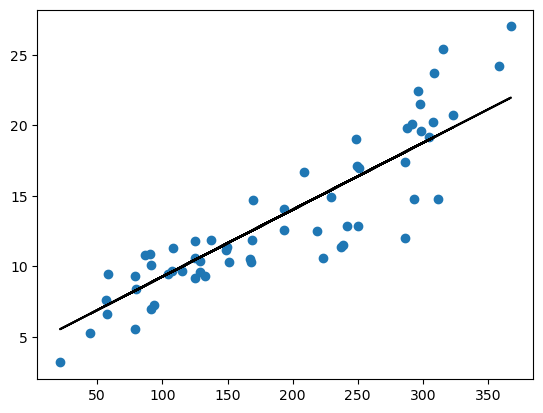

In [16]:
y_Pred=Model.predict(X_test)
plt.scatter(X_test,y_test)
plt.plot(X_test,y_Pred,color='Black')

## 2.4 Model Evaluation

### 📊 Model Evaluation Time!

Now comes the exciting part - how well does our model perform? Let's evaluate it using R² (R-squared).

#### Question 5: Interpreting the R² Score
After calculating the R² score, analyze:

1. **What does R² tell us?**
   
2. **How to interpret the score:**
   - Below 30%: Weak relationship
   - 30-70%: Moderate relationship
   - Above 70%: Strong relationship

3. **Business perspective:**
   - How much of the sales variation is explained by advertising?
   - Is this good enough for making business decisions?
   - What other factors might influence sales?

In [17]:
print("r2 score:",Model.score(X_test,y_test))

r2 score: 0.7902512827490804


### 🎯 Beyond R²: Understanding MSE

While R² gives us a good overall picture, the Mean Squared Error (MSE) provides a different perspective on our model's performance.

#### Why MSE is Important
1. **Practical Interpretation**
   - MSE is in the same units as our sales (squared)
   - Helps understand the typical prediction error
   - Larger errors are punished more heavily

2. **Business Context**
   - How far off are our sales predictions typically?
   - Are we consistently close or do we have big misses?
   - How costly would these prediction errors be?

Let's calculate the MSE and see what it tells us about our model's accuracy!

In [20]:
print("MSE:",mean_squared_error(y_test,y_Pred))

MSE: 5.921660160912177


##### Question 6: Calculate the MSE. Remember that we kept some test data on the side exactly for this purpose!

### 🔄 Training vs Testing Performance

#### Question 7: Comparing MSE Values
Calculate and compare the MSE for both training and test data:

1. **What to Look For:**
   - Is the training MSE lower than the test MSE?
   - How big is the difference?
   - What does this tell us about our model?

2. **Common Patterns:**
   - Training MSE < Test MSE: Normal (model performs better on data it's seen)
   - Training MSE >> Test MSE: Possible overfitting
   - Training MSE ≈ Test MSE: Good generalization

3. **In Linear Regression:**
   - Small differences are normal
   - Very similar values can indicate good model stability
   - Random variations might make test MSE slightly better sometimes

In [ ]:
y_train_pred = Model.predict(X_train)
y_test_pred = Model.predict(X_test)
diff = mean_squared_error(y_train,y_train_pred)-mean_squared_error(y_test,y_test_pred)
print(diff)

1.1235276401647338


## 2.5 Exercises

##### Question 1: See section 2.3
- What should we predict? (dependent variable)=dependent var is the thing which is the result or what we predict(Y)..here sales is the dependent var
- What data can we use to make predictions? (independent variables)=independent variable is the thing which we use to make the prediction(X)..here 
- Which predictions would be most valuable for the business?=sales
##### Question 2: See section 2.3
Before we start plotting, let's think about the real-world relationship between advertising and sales:
- Would you expect linear regression to work here? Why?=Yes...from the dataset i can see the more the spending in individual way the more the sales.
- What kind of relationship would you expect between ad spend and sales?=the relationship looks approx linear..sales=b0+b1(tv)+b2(radio)+b3(newspaper)
- Are there any limitations to consider?=I think the one limitation that can cause the model to distort which is outliers
##### Question 3: See section 2.3
=The testsize parameter means spliting the dataset...0.3 test size means 30% testing data...the rest is training(70%)
=the random state means controlling the random spliting...so eveytime i run it will be fixed and wont change the split
##### Question 4: See section 2.3
The solution of this question is up
##### Question 5: See section 2.4
the r2 score is 79% which is above 70 means its a strong model.
##### Question 6: See section 2.4
mse is 5.2 means typical avg sqr prediction error is 5.2...means model prediction is 5 units off from actual
##### Question 7: See section 2.4
the diff is 1.2 which is small that means the model is behaving similar to the test data

##### Question 9: In our current model we have created a new table for the total amount of advertisement. However, it is likely that The seperate budget columns have a different influence on our model. Create a model for each budget column and plot it. Compare their performance using $R^2$ and the MSE on test data. What do you notice?

##### Question 10: When we calculate the total budget, we technically have all the data in one column. However, it might be possible that there is extra value to gain when keeping the columns seperate. Build a single model with three distinct features (TV, Radio and Newspaper). Plot the model and evaluate it using $R^2$. Is this an improvement? Test the model on test data and calculate the MSE. Compare this to our current model. Is there an improvement here?

Text(0, 0.5, 'Sales')

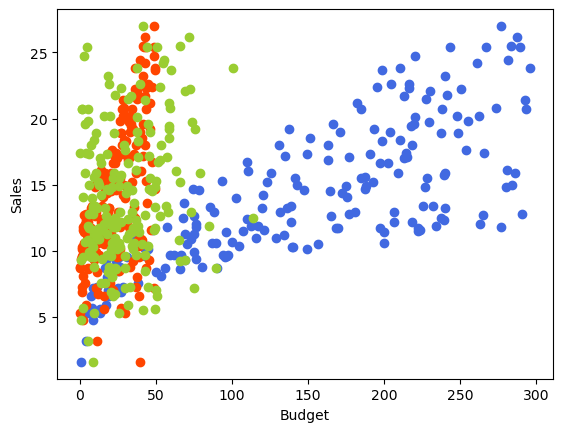

In [ ]:
plt.plot(df['TV'], df['sales'], 'o', color='royalblue')
plt.plot(df['radio'], df['sales'], 'o', color='orangered')
plt.plot(df['newspaper'], df['sales'], 'o', color='yellowgreen')
plt.xlabel('Budget')
plt.ylabel('Sales')

In [ ]:
X_full = df.drop('sales', axis=1).drop('total_spent', axis=1)
y_full = df['sales']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.3, random_state=101)

model_full = LinearRegression().fit(X_train_full,y_train_full)

In [ ]:
r_full = model_full.score(X_train_full, y_train_full)

r_full

0.8856665510409361

The $R^2$ value of our new model is 0,885. This means that about 88,5% of our data gets explained by the model. This is a huge improvement over the models of each individual column and even an improvement over our earlier model.

In [ ]:
test_predictions_full = model_full.predict(X_test_full)
MSE_full = mean_squared_error(y_test_full,test_predictions_full)

MSE_full

2.2987166978863782